# Contact-conditioning ladder — RFdiffusion de-novo peptides (6AMU / 6AM5)

**Hypothesis:** literature says the **N-terminus is the dominant MHC anchor** (M→V there raises MHC
binding, lowers TCR). So we force N-terminal MHC anchoring (**A159, A66, A70**) plus the data-derived
**TCR contacts**, and sweep the **number of conditioned interface contacts** to ask:

> Does conditioning RFdiffusion on **more interface contacts** pull the de-novo peptides toward the
> real validated binders (higher recovery / lower NLL / sharper motif)?

**Design:** 2 crystals × 5 contact-levels (3→4→5→9→12 hotspots) × 3 RFdiffusion structures →
ProteinMPNN **2000 seq/structure = 6000/condition**, T=0.1, length-10 de-novo. (`outputs/ladder/`)

In [1]:
from pathlib import Path
import glob, os, re, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
try: from IPython.display import display
except Exception: display=print
warnings.filterwarnings("ignore"); sns.set_style("whitegrid"); plt.rcParams["figure.dpi"]=110
ROOT=Path("/home/ubuntu/if-mhc"); OUT=ROOT/"outputs/ladder"
FIG=ROOT/"outputs/ladder/figures"; FIG.mkdir(parents=True,exist_ok=True)
AA=list("ACDEFGHIKLMNPQRSTVWY"); AA_IDX={a:i for i,a in enumerate(AA)}
DRG="MMWDRGLGMM"; GIG="SMLGIGIVPV"; OWN={"6AMU":DRG,"6AM5":GIG}
PANEL=['ELAGIGILTV','SMLGIGIVPV','NMGGLGIMPV','ILEDRGFNQV','LMFDRGMSLL','MMWDRGLGMM','MMWDRGMGLL','SMAGIGIVDV','IMEDVGWLNV']
# spec: (crystal, level) -> (#contacts, hotspots)
SPEC={}
for ln in open(ROOT/"inputs/focus_6am/ladder_spec.tsv"):
    p,name,nc,contig,hot=ln.rstrip("\n").split("\t"); SPEC[(p,name)]=(int(nc),hot)
LEVELS=["L1_nterm","L2_nterm_t1","L3_nterm_t2","L4_expanded","L5_max"]
spec_df=pd.DataFrame([{"crystal":p,"level":n,"n_contacts":SPEC[(p,n)][0],"hotspots":SPEC[(p,n)][1]}
                      for (p,n) in SPEC]).sort_values(["crystal","n_contacts"])
print("Contact-ladder spec:"); display(spec_df)

Contact-ladder spec:


,crystal,level,n_contacts,hotspots
5,6AM5,L1_nterm,3,"A159,A66,A70"
6,6AM5,L2_nterm_t1,4,"A159,A66,A70,E97"
7,6AM5,L3_nterm_t2,5,"A159,A66,A70,E97,D30"
8,6AM5,L4_expanded,9,"A159,A66,A70,A9,A77,A80,E97,D30,E96"
9,6AM5,L5_max,12,"A159,A66,A70,A9,A77,A80,A116,A143,E97,D30,E96,E30"
0,6AMU,L1_nterm,3,"A159,A66,A70"
1,6AMU,L2_nterm_t1,4,"A159,A66,A70,E100"
2,6AMU,L3_nterm_t2,5,"A159,A66,A70,E100,D30"
3,6AMU,L4_expanded,9,"A159,A66,A70,A9,A77,A80,E100,D30,E99"
4,6AMU,L5_max,12,"A159,A66,A70,A9,A77,A80,A116,A143,E100,D30,E99..."


## 1. Load designs per (crystal, contact-level)

In [2]:
def load_scored(globpat, L=10):
    seqs=[]; nll=[]
    for fa in glob.glob(str(globpat)):
        ls=open(fa).read().splitlines()
        for i in range(0,len(ls)-1,2):
            if "sample=" in ls[i] and len(ls[i+1].strip())==L:
                seqs.append(ls[i+1].strip())
                m=re.search(r"score=([-\d.]+)",ls[i]); nll.append(float(m.group(1)) if m else np.nan)
    return seqs, np.array(nll)
DATA={}
for (pid,name) in SPEC:
    s,nl=load_scored(OUT/f"seqs/{pid}_{name}_*.fa")
    if s: DATA[(pid,name)]=(s,nl)
print("loaded conditions:", len(DATA), "/", len(SPEC))
inv=pd.DataFrame([{"crystal":p,"level":n,"n_contacts":SPEC[(p,n)][0],"n_seq":len(DATA[(p,n)][0]),
                   "pct_unique":round(100*len(set(DATA[(p,n)][0]))/len(DATA[(p,n)][0]),1),
                   "median_NLL":round(np.nanmedian(DATA[(p,n)][1]),3)}
                  for (p,n) in DATA]).sort_values(["crystal","n_contacts"])
display(inv)

loaded conditions: 10 / 10


,crystal,level,n_contacts,n_seq,pct_unique,median_NLL
5,6AM5,L1_nterm,3,6000,4.0,1.074
6,6AM5,L2_nterm_t1,4,6000,4.1,1.032
7,6AM5,L3_nterm_t2,5,6000,10.2,1.235
8,6AM5,L4_expanded,9,6000,4.2,1.061
9,6AM5,L5_max,12,6000,5.1,1.086
0,6AMU,L1_nterm,3,6000,5.7,1.108
1,6AMU,L2_nterm_t1,4,6000,10.4,1.146
2,6AMU,L3_nterm_t2,5,6000,9.9,1.147
3,6AMU,L4_expanded,9,6000,10.1,1.166
4,6AMU,L5_max,12,6000,5.1,0.979


## 2. Recovery vs number of conditioned contacts

,crystal,level,n_contacts,max->own,mean->own,max->panel,median_NLL
5,6AM5,L1_nterm,3,40.0,7.0,40.0,1.074
6,6AM5,L2_nterm_t1,4,20.0,4.7,20.0,1.032
7,6AM5,L3_nterm_t2,5,20.0,4.3,30.0,1.235
8,6AM5,L4_expanded,9,30.0,7.6,30.0,1.061
9,6AM5,L5_max,12,40.0,16.4,40.0,1.086
0,6AMU,L1_nterm,3,20.0,8.5,30.0,1.108
1,6AMU,L2_nterm_t1,4,20.0,9.3,30.0,1.146
2,6AMU,L3_nterm_t2,5,30.0,13.0,50.0,1.147
3,6AMU,L4_expanded,9,20.0,12.7,30.0,1.166
4,6AMU,L5_max,12,30.0,15.3,30.0,0.979


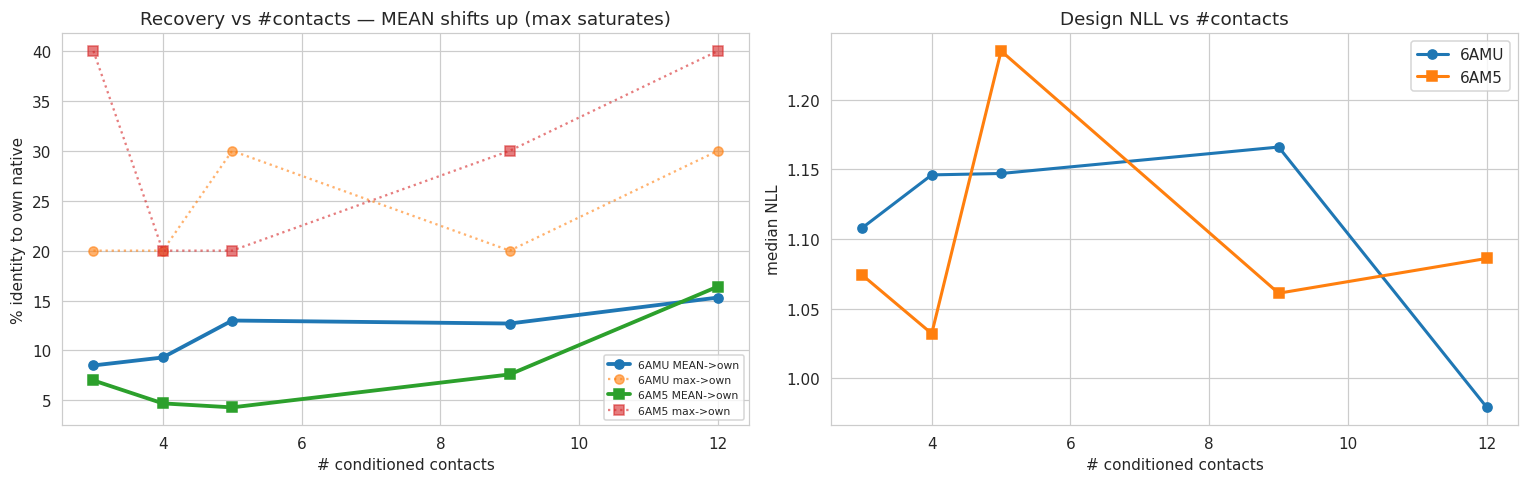

MEAN identity to native ~DOUBLES L1->L5 (the distribution shifts toward native); max saturates.


In [3]:
def maxid(seqs,ref):
    if not seqs: return 0.0
    P=np.array([list(x) for x in seqs]); return float((P==np.array(list(ref))).mean(1).max()*100)
def meanid(seqs,ref):
    if not seqs: return 0.0
    P=np.array([list(x) for x in seqs]); return float((P==np.array(list(ref))).mean(1).mean()*100)
def best_panel(seqs): return max(maxid(seqs,p) for p in PANEL)
rows=[]
for (pid,name),(s,nl) in DATA.items():
    nc=SPEC[(pid,name)][0]
    rows.append({"crystal":pid,"level":name,"n_contacts":nc,
                 "max->own":round(maxid(s,OWN[pid]),0),"mean->own":round(meanid(s,OWN[pid]),1),
                 "max->panel":round(best_panel(s),0),"median_NLL":round(np.nanmedian(nl),3)})
lad=pd.DataFrame(rows).sort_values(["crystal","n_contacts"]); display(lad)
fig,ax=plt.subplots(1,2,figsize=(14,4.5))
for pid,mk in [("6AMU","o"),("6AM5","s")]:
    sub=lad[lad.crystal==pid].sort_values("n_contacts")
    if len(sub):
        ax[0].plot(sub.n_contacts,sub["mean->own"],marker=mk,lw=2.5,label=f"{pid} MEAN->own")
        ax[0].plot(sub.n_contacts,sub["max->own"],marker=mk,ls=":",lw=1.5,alpha=.6,label=f"{pid} max->own")
ax[0].set_xlabel("# conditioned contacts"); ax[0].set_ylabel("% identity to own native"); ax[0].legend(fontsize=7)
ax[0].set_title("Recovery vs #contacts — MEAN shifts up (max saturates)")
for pid,mk in [("6AMU","o"),("6AM5","s")]:
    sub=lad[lad.crystal==pid].sort_values("n_contacts")
    if len(sub): ax[1].plot(sub.n_contacts,sub["median_NLL"],marker=mk,lw=2,label=pid)
ax[1].set_xlabel("# conditioned contacts"); ax[1].set_ylabel("median NLL"); ax[1].legend()
ax[1].set_title("Design NLL vs #contacts")
plt.tight_layout(); plt.savefig(FIG/"ladder_recovery_nll.png",bbox_inches="tight"); plt.show()
print("MEAN identity to native ~DOUBLES L1->L5 (the distribution shifts toward native); max saturates.")

### 2b. Per-position recovery vs #contacts — WHICH residues respond to conditioning

The decisive view: per-position identity to the native, as a heatmap of position × contact-level.
Conditioning on MHC pocket contacts should recover the **anchor** residues (P2/N-term, C-terminal),
while the central TCR-facing core stays unrecovered.

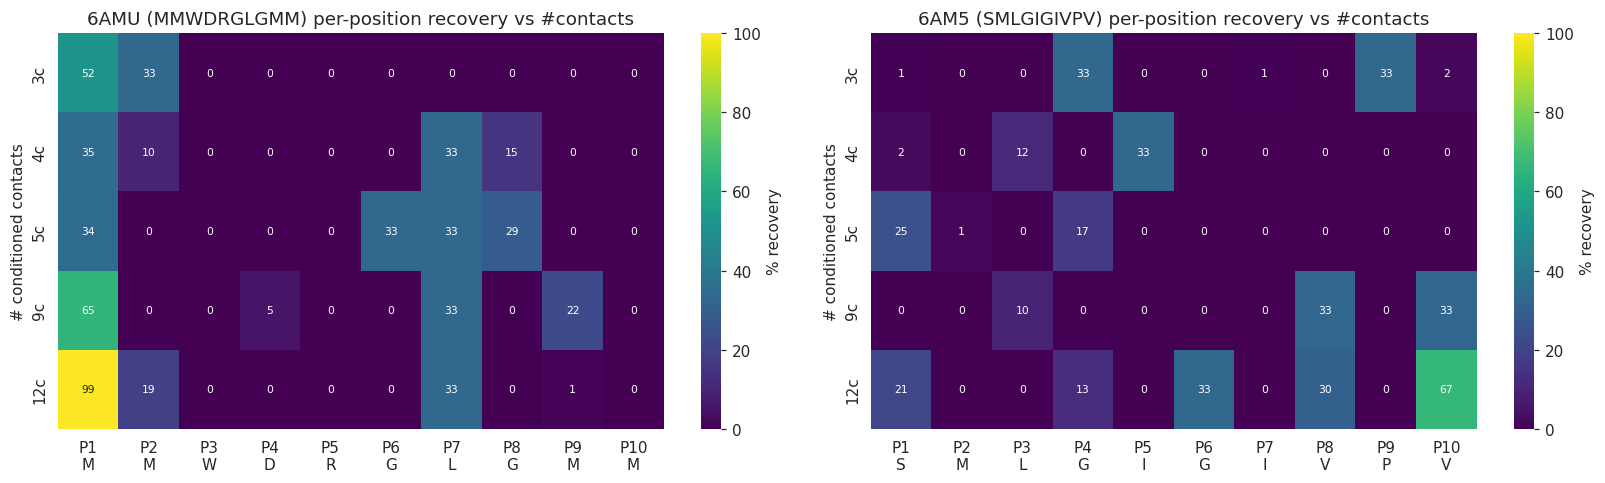

Anchor positions (N-term, C-term) light up with more contacts (esp. 6AM5 P10-Val ->67% at 12c);
central TCR-facing core (P3-P8) stays ~0 -> conditioning recovers MHC anchors, not the TCR face.


In [4]:
def perpos(seqs,nat):
    P=np.array([list(x) for x in seqs]); return (P==np.array(list(nat))).mean(0)*100
fig,axes=plt.subplots(1,2,figsize=(15,4.5))
for ax,pid in zip(axes,["6AMU","6AM5"]):
    nat=OWN[pid]
    levs=[l for l in LEVELS if (pid,l) in DATA]
    M=np.array([perpos(DATA[(pid,l)][0],nat) for l in levs])   # levels x positions
    nc=[SPEC[(pid,l)][0] for l in levs]
    sns.heatmap(M,ax=ax,cmap="viridis",vmin=0,vmax=100,annot=True,fmt=".0f",annot_kws={"size":7},
                xticklabels=[f"P{i+1}\n{nat[i]}" for i in range(10)],
                yticklabels=[f"{c}c" for c in nc],cbar_kws={"label":"% recovery"})
    ax.set_title(f"{pid} ({nat}) per-position recovery vs #contacts"); ax.set_ylabel("# conditioned contacts")
plt.tight_layout(); plt.savefig(FIG/"ladder_perposition.png",bbox_inches="tight"); plt.show()
print("Anchor positions (N-term, C-term) light up with more contacts (esp. 6AM5 P10-Val ->67% at 12c);")
print("central TCR-facing core (P3-P8) stays ~0 -> conditioning recovers MHC anchors, not the TCR face.")

## 3. Diversity vs number of conditioned contacts

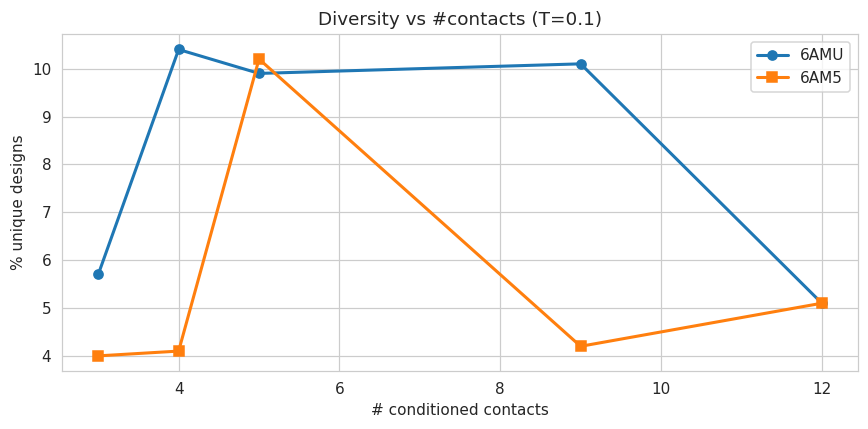

In [5]:
fig,ax=plt.subplots(figsize=(8,4))
for pid,mk in [("6AMU","o"),("6AM5","s")]:
    sub=inv[inv.crystal==pid].sort_values("n_contacts")
    if len(sub): ax.plot(sub.n_contacts,sub.pct_unique,marker=mk,lw=2,label=pid)
ax.set_xlabel("# conditioned contacts"); ax.set_ylabel("% unique designs"); ax.legend()
ax.set_title("Diversity vs #contacts (T=0.1)")
plt.tight_layout(); plt.savefig(FIG/"ladder_diversity.png",bbox_inches="tight"); plt.show()

## 4. Sequence logos per contact-level (does the motif sharpen with more contacts?)

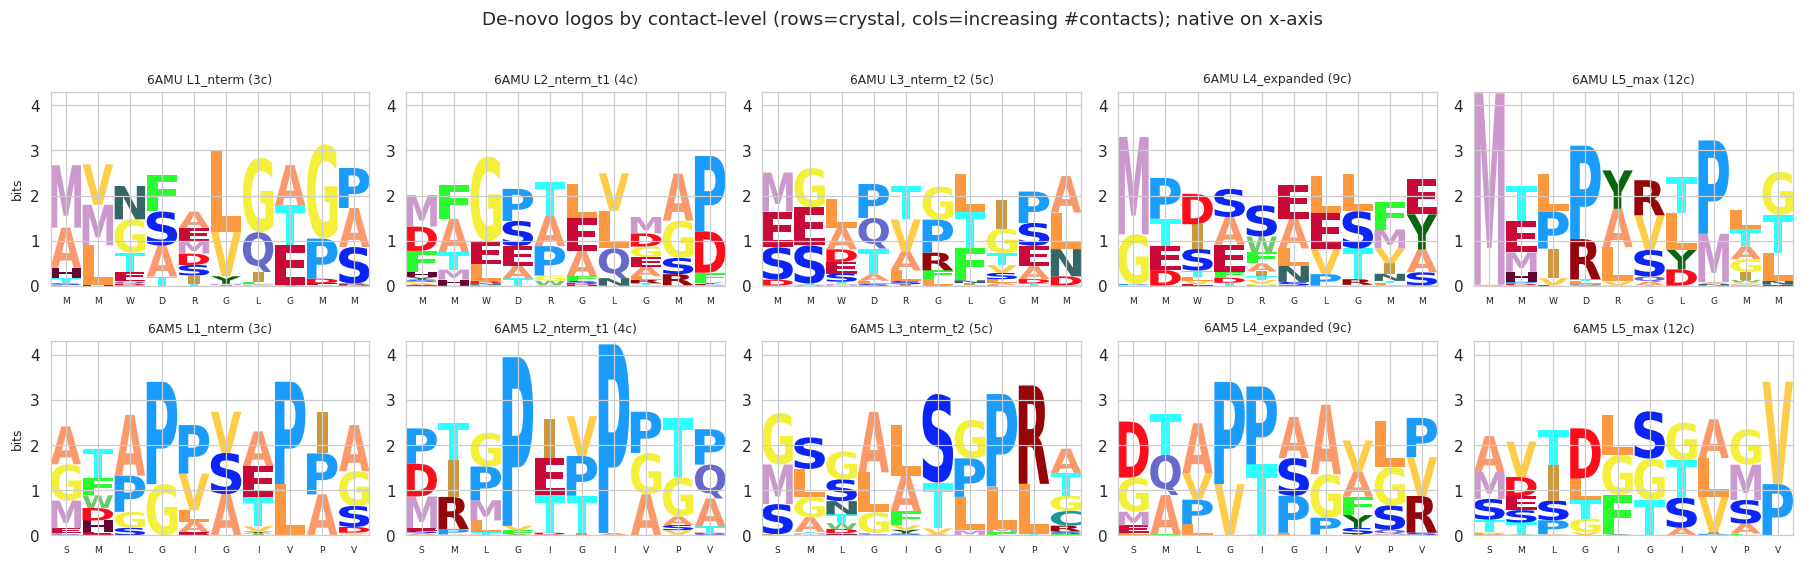

In [6]:
import logomaker
def freq(seqs,L=10):
    M=np.zeros((L,len(AA)))
    for s in seqs:
        for i,c in enumerate(s):
            if i<L and c in AA_IDX: M[i,AA_IDX[c]]+=1
    M/=np.clip(M.sum(1,keepdims=True),1,None); return pd.DataFrame(M,columns=AA,index=list(range(L)))
present=[l for l in LEVELS if any((p,l) in DATA for p in ["6AMU","6AM5"])]
fig,axes=plt.subplots(2,len(present),figsize=(3.3*len(present),5),squeeze=False)
for r,pid in enumerate(["6AMU","6AM5"]):
    for c,lvl in enumerate(present):
        ax=axes[r][c]
        if (pid,lvl) not in DATA: ax.set_axis_off(); continue
        s=DATA[(pid,lvl)][0]; nc=SPEC[(pid,lvl)][0]
        info=logomaker.transform_matrix(freq(s).copy(),from_type="probability",to_type="information")
        logomaker.Logo(info,ax=ax,color_scheme="skylign_protein"); ax.set_ylim(0,4.3)
        ax.set_title(f"{pid} {lvl} ({nc}c)",fontsize=8)
        ax.set_xticks(range(10)); ax.set_xticklabels(list(OWN[pid]),fontsize=6)
        if c==0: ax.set_ylabel("bits",fontsize=8)
plt.suptitle("De-novo logos by contact-level (rows=crystal, cols=increasing #contacts); native on x-axis",y=1.02)
plt.tight_layout(); plt.savefig(FIG/"ladder_logos.png",bbox_inches="tight"); plt.show()

## 5. L1 (fewest) vs L5 (most contacts) — summary

In [7]:
for pid in ["6AMU","6AM5"]:
    a=lad[(lad.crystal==pid)].sort_values("n_contacts")
    if len(a)<2: continue
    lo=a.iloc[0]; hi=a.iloc[-1]
    print(f"{pid}: L1 ({lo.n_contacts}c) max->own {lo['max->own']:.0f}% / panel {lo['max->panel']:.0f}% / NLL {lo.median_NLL:.3f}")
    print(f"     L5 ({hi.n_contacts}c) max->own {hi['max->own']:.0f}% / panel {hi['max->panel']:.0f}% / NLL {hi.median_NLL:.3f}")
    print(f"     Δ(L5-L1): own {hi['max->own']-lo['max->own']:+.0f}%  panel {hi['max->panel']-lo['max->panel']:+.0f}%  NLL {hi.median_NLL-lo.median_NLL:+.3f}\n")
lad.to_csv(OUT/"ladder_summary.csv",index=False)
print("saved outputs/ladder/ladder_summary.csv")

6AMU: L1 (3c) max->own 20% / panel 30% / NLL 1.108
     L5 (12c) max->own 30% / panel 30% / NLL 0.979
     Δ(L5-L1): own +10%  panel +0%  NLL -0.129

6AM5: L1 (3c) max->own 40% / panel 40% / NLL 1.074
     L5 (12c) max->own 40% / panel 40% / NLL 1.086
     Δ(L5-L1): own +0%  panel +0%  NLL +0.012

saved outputs/ladder/ladder_summary.csv


**Caveat — this is a sequence-identity (ProteinMPNN) signal, not a structural one.** The mean-identity
gain from L1->L5 above was NOT reproduced when the same question was asked structurally: a later,
larger sweep (up to 42 hotspots, ~1300 designs, register-preserving Cα-RMSD + F-pocket occupancy) found
hotspot count barely correlates with structural recovery quality (Spearman rho ~ 0.17) and geometric
motif-templating — not contact count — is what determines whether the backbone lands near native
(fix8/10 residues templated -> 0.39 A vs 42 hotspots alone -> ~2 A floor). Read this notebook's
mean-identity-doubles finding as "conditioning shapes which sequences ProteinMPNN proposes on a GIVEN
backbone," not as evidence that more contacts get RFdiffusion closer to the correct backbone geometry.